In [2]:
import pandas as pd

df = pd.read_excel("data/google_fully_cleaned.xlsx")

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_excel("data/google_fully_cleaned.xlsx")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Facebook,SOCIAL,4.1,78158306,12000.0,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device,3,8,2018
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,12000.0,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device,3,8,2018
2,Instagram,SOCIAL,4.5,66577446,12000.0,1000000000,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device,31,7,2018
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,12000.0,1000000000,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device,1,8,2018
4,Clash of Clans,GAME,4.6,44893888,98000.0,100000000,Free,0.0,Everyone 10+,Strategy,2018-07-15,10.322.16,4.1 and up,15,7,2018


In [5]:
df.shape

(9658, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9658 entries, 0 to 9657
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9658 non-null   str           
 1   Category        9658 non-null   str           
 2   Rating          8196 non-null   float64       
 3   Reviews         9658 non-null   int64         
 4   Size            9658 non-null   float64       
 5   Installs        9658 non-null   int64         
 6   Type            9658 non-null   str           
 7   Price           9658 non-null   float64       
 8   Content Rating  9658 non-null   str           
 9   Genres          9658 non-null   str           
 10  Last Updated    9658 non-null   datetime64[us]
 11  Current Ver     9650 non-null   str           
 12  Android Ver     9656 non-null   str           
 13  Day             9658 non-null   int64         
 14  Month           9658 non-null   int64         
 15  Year           

In [7]:
df.describe()

,Rating,Reviews,Size,Installs,Price,Last Updated,Day,Month,Year
count,8196.000000,9.658000e+03,9658.000000,9.658000e+03,9658.000000,9658,9658.000000,9658.000000,9658.000000
mean,4.173267,2.168266e+05,17565.784811,7.798978e+06,1.097344,2017-10-30 23:07:39.971008,15.621868,6.363843,2017.346138
min,1.000000,0.000000e+00,1.000000,0.000000e+00,0.000000,2010-05-21 00:00:00,1.000000,1.000000,2010.000000
25%,4.000000,2.500000e+01,6.200000,1.000000e+03,0.000000,2017-08-07 00:00:00,7.000000,5.000000,2017.000000
50%,4.300000,9.695000e+02,12000.000000,1.000000e+05,0.000000,2018-05-04 00:00:00,16.000000,7.000000,2018.000000
75%,4.500000,2.945775e+04,25000.000000,1.000000e+06,0.000000,2018-07-17 00:00:00,24.000000,8.000000,2018.000000
max,5.000000,7.815831e+07,100000.000000,1.000000e+09,400.000000,2018-08-08 00:00:00,31.000000,12.000000,2018.000000
std,0.536253,1.831524e+06,21866.528913,5.377245e+07,16.852487,NaN,9.431226,2.660514,1.137437


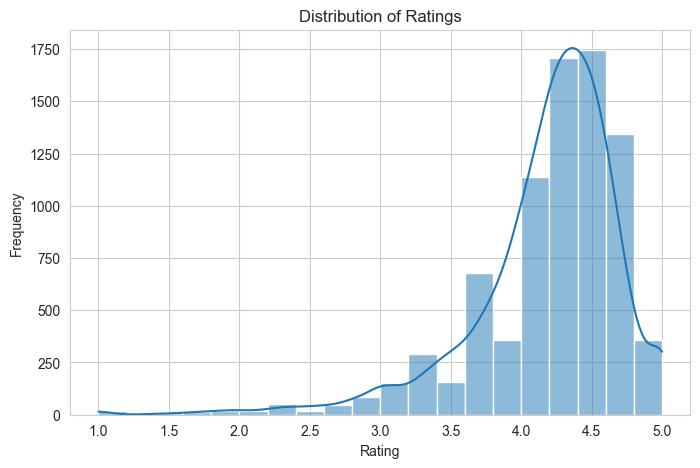

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=20, kde=True)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

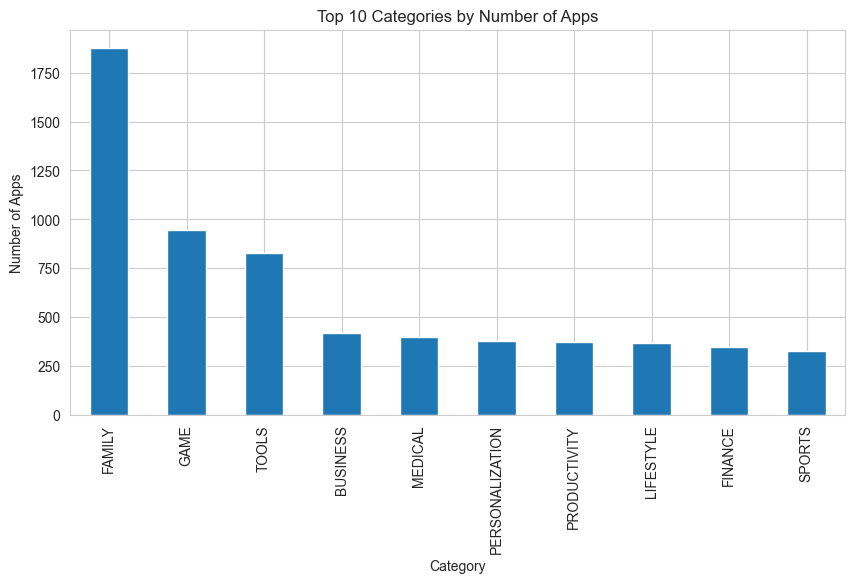

In [9]:
top_categories = df["Category"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_categories.plot(kind="bar")

plt.title("Top 10 Categories by Number of Apps")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.show()

In [10]:
!pip install squarify

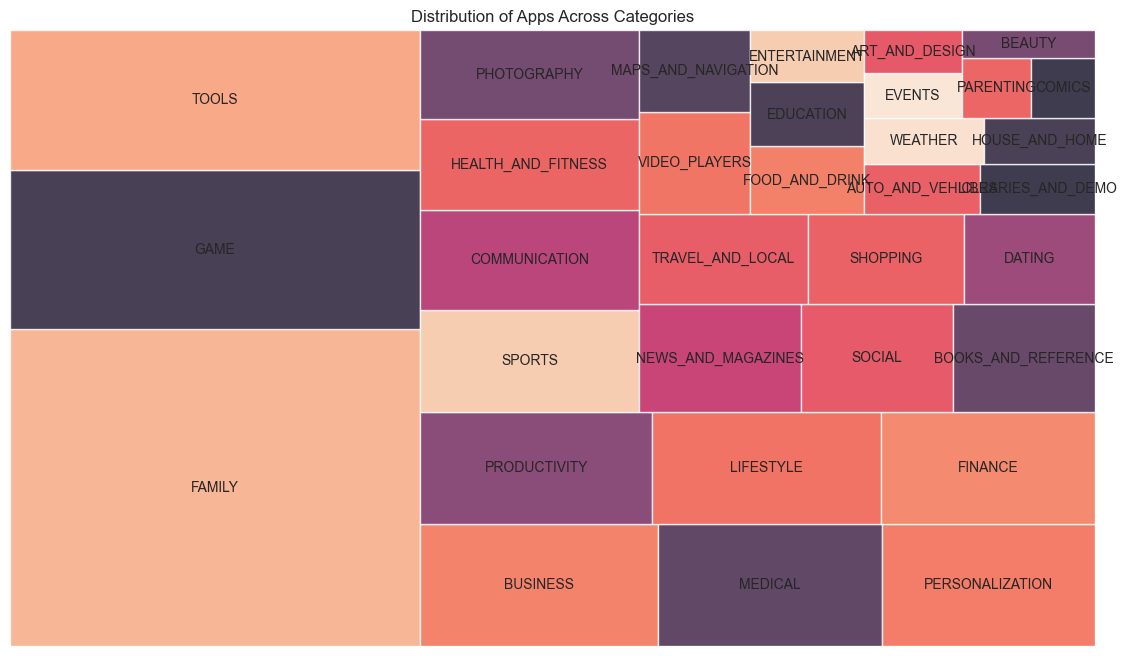

In [11]:
import squarify
import matplotlib.pyplot as plt

category_counts = df['Category'].value_counts()

plt.figure(figsize=(14,8))

squarify.plot(
    sizes=category_counts.values,
    label=category_counts.index,
    alpha=0.8
)

plt.axis('off')

plt.title("Distribution of Apps Across Categories")

plt.show()

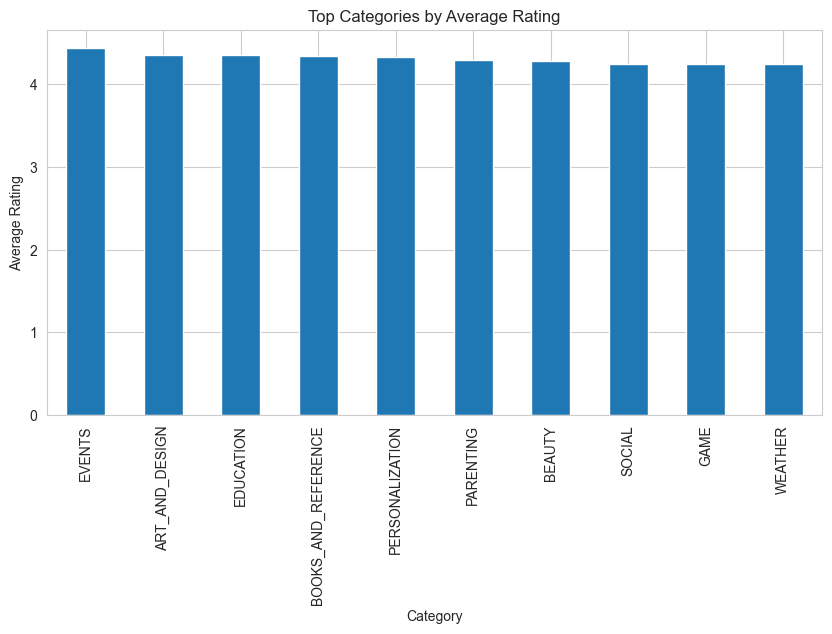

In [12]:
category_rating = (df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10,5))

category_rating.plot(kind="bar")

plt.title("Top Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.show()

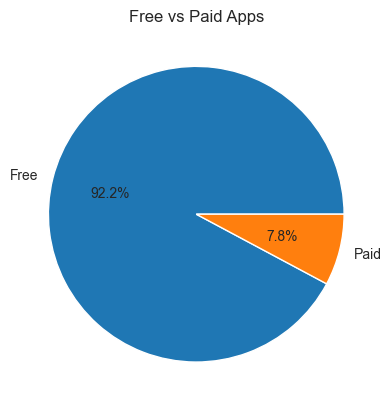

In [13]:
df["Type"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.title("Free vs Paid Apps")
plt.ylabel("")

plt.show()

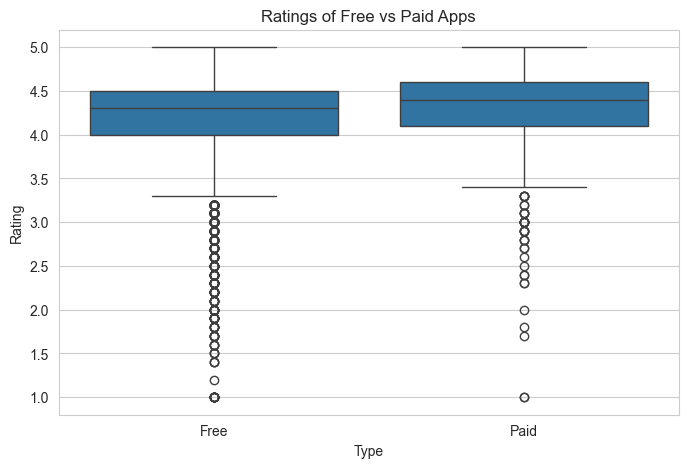

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Type",
    y="Rating",
    data=df
)

plt.title("Ratings of Free vs Paid Apps")

plt.show()

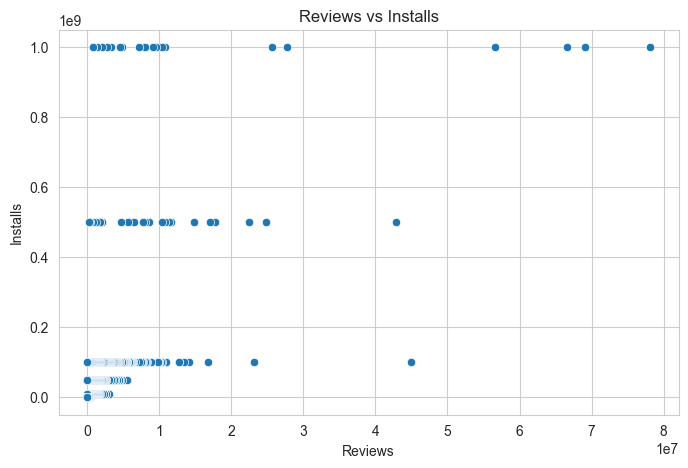

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Reviews",
    y="Installs",
    data=df
)

plt.title("Reviews vs Installs")

plt.show()

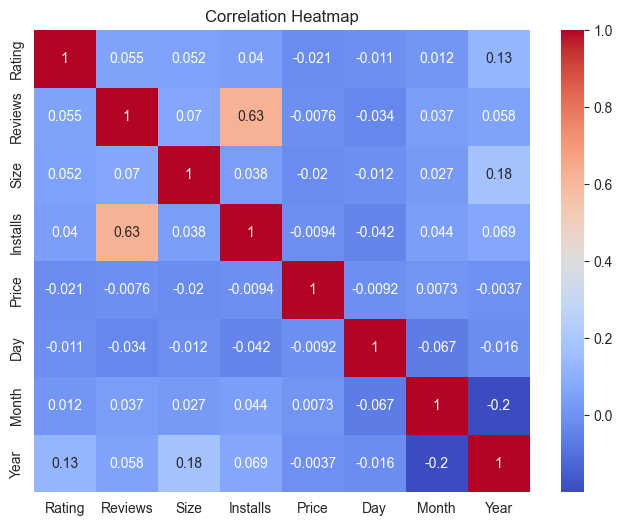

In [16]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

<Axes: >

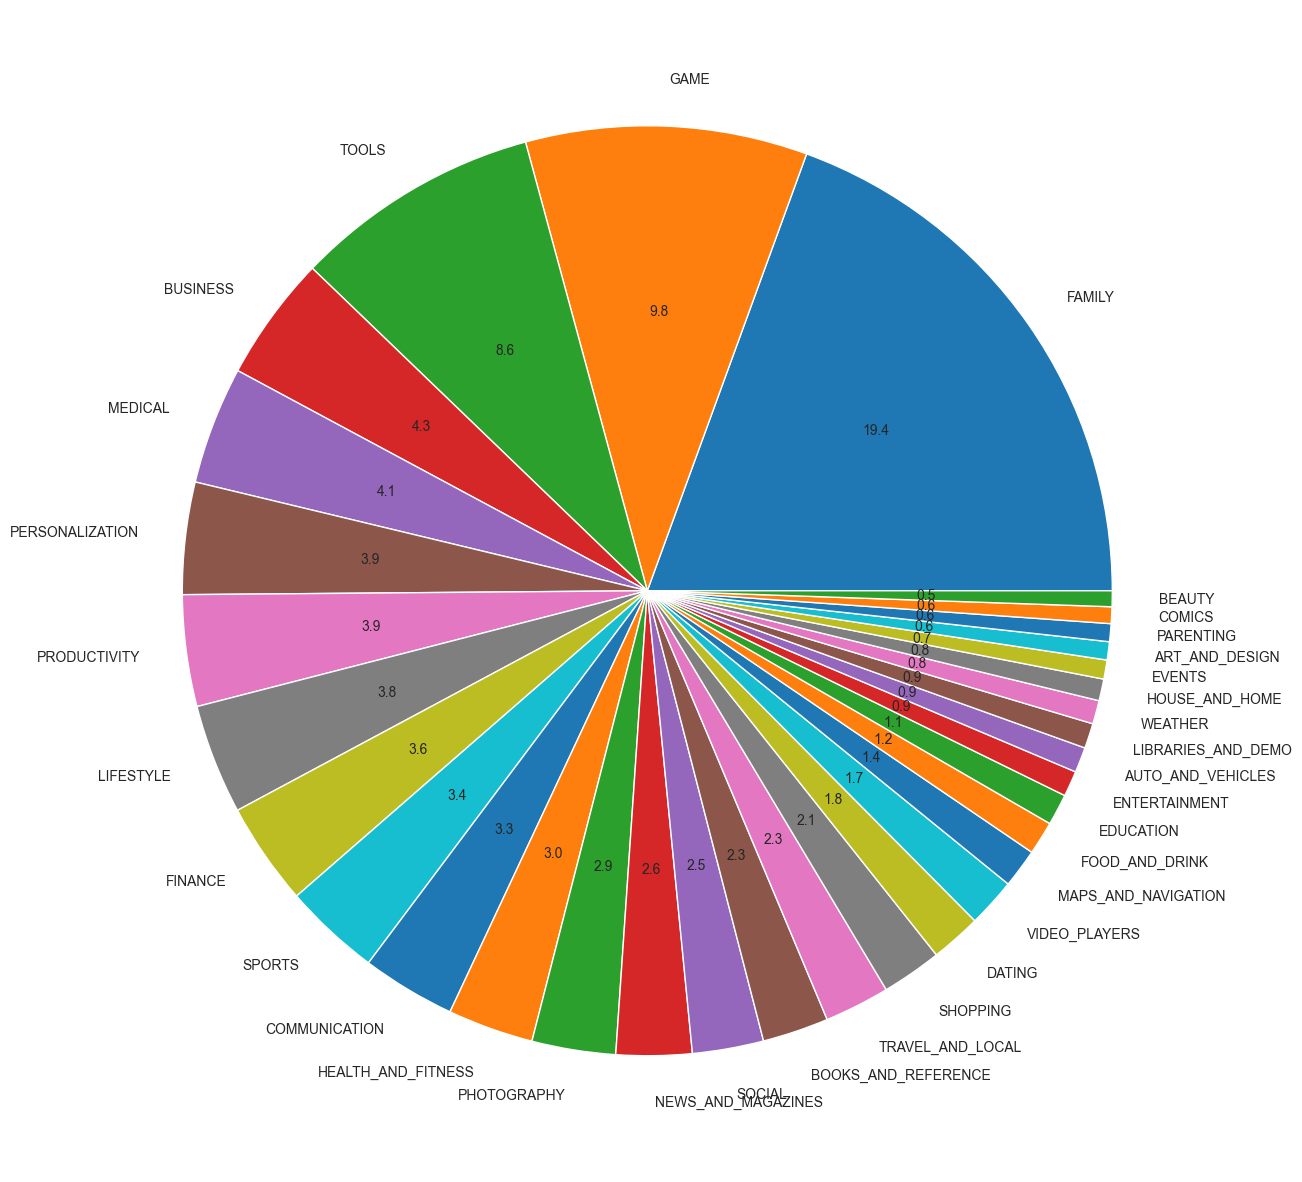

In [17]:
df['Category'].value_counts().plot.pie(y=df['Category'],figsize=(15,16),autopct='%1.1f')

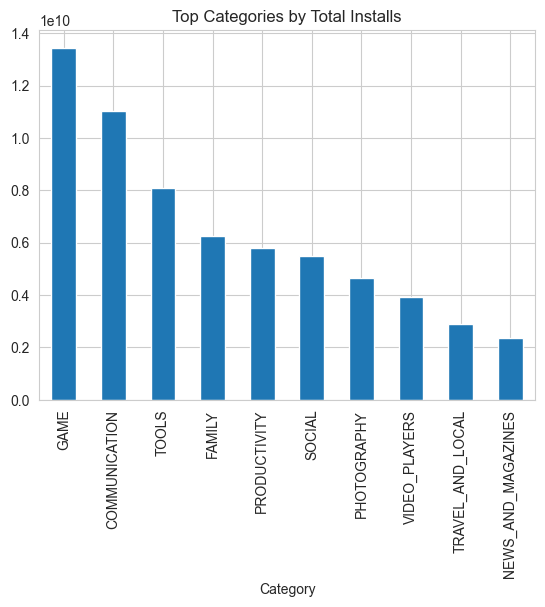

In [18]:
category_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

category_installs.plot(kind='bar')
plt.title("Top Categories by Total Installs")
plt.show()

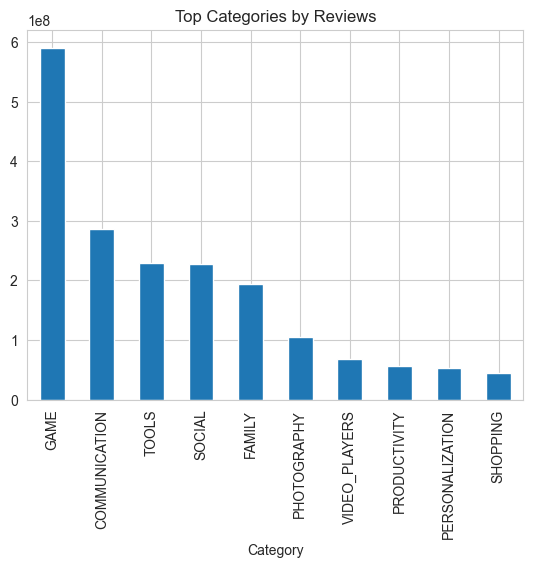

In [19]:
category_reviews = df.groupby('Category')['Reviews'].sum().sort_values(ascending=False).head(10)

category_reviews.plot(kind='bar')
plt.title("Top Categories by Reviews")
plt.show()

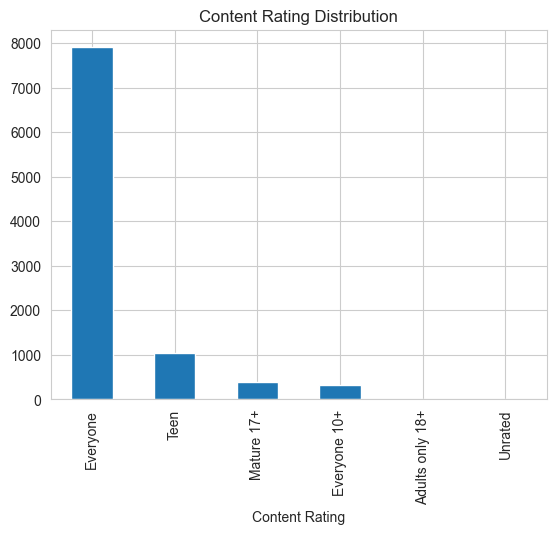

In [20]:
df['Content Rating'].value_counts().plot(kind='bar')
plt.title("Content Rating Distribution")
plt.show()

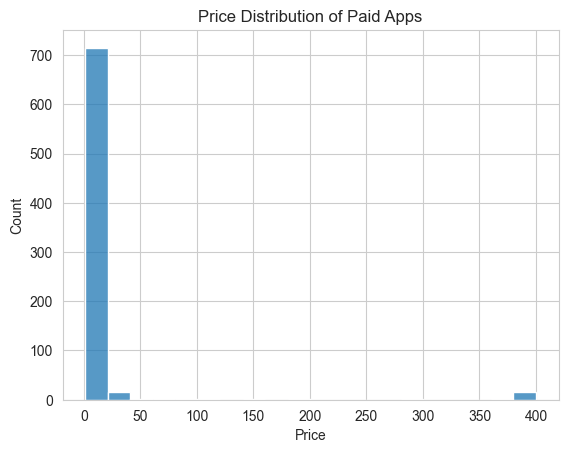

In [21]:
paid_apps = df[df['Type']=='Paid']

sns.histplot(paid_apps['Price'], bins=20)
plt.title("Price Distribution of Paid Apps")
plt.show()

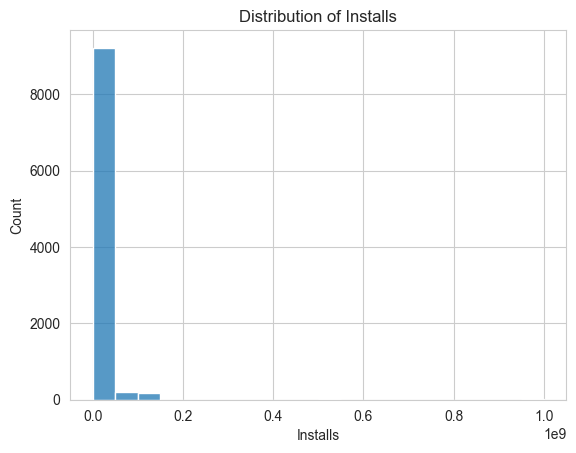

In [22]:
sns.histplot(df['Installs'], bins=20)
plt.title("Distribution of Installs")
plt.show()

In [23]:
top_apps = df.nlargest(10,'Installs')[['App','Installs']]
top_apps

,App,Installs
0,Facebook,1000000000
1,WhatsApp Messenger,1000000000
2,Instagram,1000000000
3,Messenger – Text and Video Chat for Free,1000000000
6,Subway Surfers,1000000000
7,YouTube,1000000000
22,Google Photos,1000000000
25,Skype - free IM & video calls,1000000000
33,Google Chrome: Fast & Secure,1000000000
34,Maps - Navigate & Explore,1000000000


In [24]:
df['Popular_App'] = (df['Installs'] > 1000000).astype(int)

In [25]:
df[['Popular_App','Installs']]

,Popular_App,Installs
0,1,1000000000
1,1,1000000000
2,1,1000000000
3,1,1000000000
4,1,100000000
...,...,...
9653,0,100
9654,0,10
9655,0,10
9656,0,10


In [27]:
df.to_excel("google_playstore_cleaned_final.xlsx", index=False)